In [11]:
import os, sys
from pathlib import Path

# Navigating to project root — idempotent, safe to re-run
PROJECT_ROOT = Path(__file__).resolve().parent.parent if '__file__' in dir() else Path(os.getcwd())
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv()

print("Setup done.")

Setup done.


In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Importing modules done.")

Importing modules done.


In [13]:
df = pd.read_csv("results/eval_results.csv")
print(f"Loading eval results — {len(df)} rows loaded.")
print(df["failure_type"].value_counts(dropna=False))

Loading eval results — 35 rows loaded.
failure_type
NaN                 27
TOOL_CALL_FAILED     5
LOOP_DETECTED        3
Name: count, dtype: int64


In [14]:
failure_counts = df["failure_type"].value_counts(dropna=False)
failure_counts.index = failure_counts.index.fillna("NO_FAILURE")

print("\n=== FAILURE TYPE COUNTS ===")
for ftype, count in failure_counts.items():
    print(f"  {ftype:20} : {count}")

Path("results").mkdir(exist_ok=True)


=== FAILURE TYPE COUNTS ===
  NO_FAILURE           : 27
  TOOL_CALL_FAILED     : 5
  LOOP_DETECTED        : 3



=== CATEGORY × FAILURE TYPE ===
failure_type  LOOP_DETECTED  NO_FAILURE  TOOL_CALL_FAILED
category                                                 
conceptual                2          12                 3
factual                   1          13                 1
multi-hop                 0           2                 1


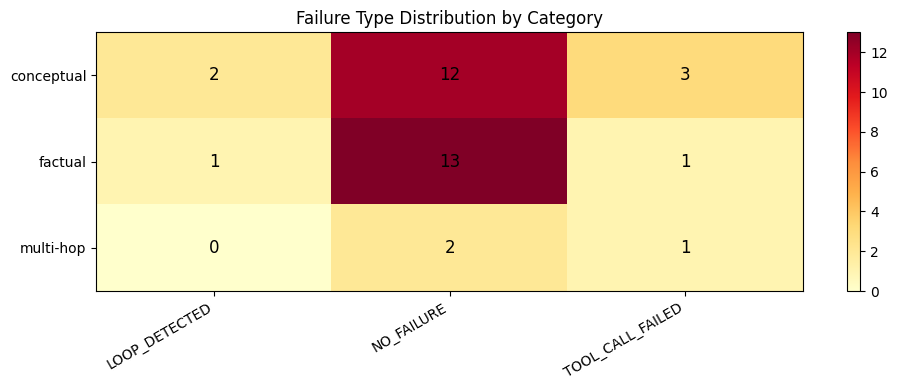

Saving failure heatmap — done.


In [15]:
heatmap_data = df.copy()
heatmap_data["failure_type"] = heatmap_data["failure_type"].fillna("NO_FAILURE")

pivot = pd.crosstab(heatmap_data["category"], heatmap_data["failure_type"])
print("\n=== CATEGORY × FAILURE TYPE ===")
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, pivot.values[i, j], ha="center", va="center", fontsize=12)
plt.colorbar(im, ax=ax)
ax.set_title("Failure Type Distribution by Category")
plt.tight_layout()
plt.savefig("results/failure_heatmap.png", dpi=150)
plt.show()
print("Saving failure heatmap — done.")

In [16]:
no_failure_counts = failure_counts.drop("NO_FAILURE", errors="ignore")
if not no_failure_counts.empty:
    most_common = no_failure_counts.idxmax()
    print(f"Most common failure type: {most_common} ({no_failure_counts[most_common]} occurrences)")
else:
    print("No failures detected.")

Most common failure type: TOOL_CALL_FAILED (5 occurrences)


In [17]:
taxonomy_df = pd.DataFrame({
    "failure_type": failure_counts.index,
    "count":        failure_counts.values,
    "pct":          (failure_counts.values / len(df) * 100).round(2),
})
taxonomy_df.to_csv("results/failure_taxonomy.csv", index=False, encoding="utf-8")
print("Saving failure taxonomy — done.")
print(taxonomy_df.to_string(index=False))

Saving failure taxonomy — done.
    failure_type  count   pct
      NO_FAILURE     27 77.14
TOOL_CALL_FAILED      5 14.29
   LOOP_DETECTED      3  8.57
